# Notebook 2 — Generación de edificios + análisis modal completo

Este notebook carga la **Familia B oficial exportada desde el Notebook 1** y la transforma en modelos estructurales reducidos para análisis modal.

Objetivo:

$$
\text{Familia B exportada} \rightarrow \text{Modelo dinámico} \rightarrow \text{Análisis modal} \rightarrow \text{Auditoría}
$$

Este notebook **no aplica todavía** espectro NCh433 completo, CQC, torsión accidental ni corte basal. Eso queda para el Notebook 3.

La Familia B se toma desde:

```text
C:\Users\rodri\Documents\PINN\b2_proyecto\notebooks\outputs\familia_B\familia_B_master.json
C:\Users\rodri\Documents\PINN\b2_proyecto\notebooks\outputs\familia_B\familia_B_core.py
```


## 🔧 Hito — Imports y configuración global

Punto de arranque del notebook. Importa las librerías de cálculo (NumPy, Pandas, Matplotlib), detecta de forma tolerante la disponibilidad de **SciPy** (`scipy.linalg.eigh`, solver del problema modal) y de **OpenSeesPy**, fijando banderas `SCIPY_AVAILABLE` / `OPENSEES_AVAILABLE` sin abortar si faltan. Define la constante de gravedad, las **rutas oficiales** al JSON y al `core.py` exportados por el Notebook 1, y los parámetros de la corrida modal: `N_MODOS_MAX = 36`, `SEED_AUDIT = 2026` y `N_MUESTRAS_AUDIT = 12`.

**Se obtiene:** el entorno configurado, las banderas de disponibilidad de solvers y las rutas/constantes que gobiernan todo el notebook.

In [1]:
# ============================================================
# CELDA 1 — IMPORTS Y CONFIGURACIÓN GENERAL
# ============================================================
from pathlib import Path
import math
import pickle
import json
import sys
import importlib
from pprint import pprint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

G_ACCEL = 9.80665

try:
    from scipy.linalg import eigh
    SCIPY_AVAILABLE = True
except Exception as e:
    SCIPY_AVAILABLE = False
    print("ADVERTENCIA: scipy.linalg.eigh no disponible:", repr(e))

try:
    import openseespy.opensees as ops
    OPENSEES_AVAILABLE = True
except Exception as e:
    OPENSEES_AVAILABLE = False
    print("ADVERTENCIA: OpenSeesPy no disponible. Se usará solver matricial:", repr(e))

# ------------------------------------------------------------
# Ruta oficial exportada desde el Notebook 1
# ------------------------------------------------------------
FAMILIA_B_JSON = Path(r"C:\Users\rodri\Documents\PINN\b2_proyecto\notebooks\outputs\familia_B\familia_B_master.json")
FAMILIA_B_CORE = Path(r"C:\Users\rodri\Documents\PINN\b2_proyecto\notebooks\outputs\familia_B\familia_B_core.py")
FAMILIA_B_DIR  = FAMILIA_B_JSON.parent

# Configuración modal del Notebook 2
N_MODOS_MAX = 36
SEED_AUDIT = 2026
N_MUESTRAS_AUDIT = 12

print("SciPy disponible    :", SCIPY_AVAILABLE)
print("OpenSeesPy disponible:", OPENSEES_AVAILABLE)
print("JSON Familia B      :", FAMILIA_B_JSON)
print("CORE Familia B      :", FAMILIA_B_CORE)


SciPy disponible    : True
OpenSeesPy disponible: True
JSON Familia B      : C:\Users\rodri\Documents\PINN\b2_proyecto\notebooks\outputs\familia_B\familia_B_master.json
CORE Familia B      : C:\Users\rodri\Documents\PINN\b2_proyecto\notebooks\outputs\familia_B\familia_B_core.py


## 📥 Hito — Carga oficial de la Familia B (desde Notebook 1)

Celda clave de **trazabilidad**: el Notebook 2 **no redefine** la tipología, solo consume los artefactos del Notebook 1. Verifica que existan el JSON y el `core.py`, agrega la carpeta oficial al `sys.path`, **recarga** `familia_B_core` (descartando cualquier versión previa en memoria) e importa sus funciones (`build_params_B`, `build_family_B_geometry`, ploteos, etc.). Carga `FAMILIA_B_CFG` desde el JSON y aplica **asserts de consistencia** con la versión final: nombre de familia, rango de pisos $[6, 18]$, suelos $\{A,B,C,D\}$ y la regla `tech_bays_each_side = 1`.

**Se obtiene:** las funciones núcleo y la configuración `FAMILIA_B_CFG` validadas, garantizando que el análisis modal opera sobre la familia oficial y no sobre una copia desactualizada.

In [2]:
# ============================================================
# CELDA 2 — CARGA OFICIAL DE LA FAMILIA B EXPORTADA DESDE NOTEBOOK 1
# ============================================================
# Esta celda reemplaza la carga directa del notebook .ipynb.
# Notebook 2 NO redefine la Familia B: solo consume el JSON y el CORE
# exportados por Notebook 1.

if not FAMILIA_B_JSON.exists():
    raise FileNotFoundError(
        f"No existe el archivo JSON oficial de la Familia B:\n{FAMILIA_B_JSON}\n"
        "Ejecuta primero Notebook 1 completo y su celda de exportación."
    )

if not FAMILIA_B_CORE.exists():
    raise FileNotFoundError(
        f"No existe el archivo CORE oficial de la Familia B:\n{FAMILIA_B_CORE}\n"
        "Ejecuta primero Notebook 1 completo y su celda de exportación."
    )

# Asegurar que Python pueda importar familia_B_core.py desde la carpeta oficial.
core_dir_str = str(FAMILIA_B_DIR.resolve())
if core_dir_str not in sys.path:
    sys.path.insert(0, core_dir_str)

# Si ya había una versión cargada en memoria, la eliminamos para evitar usar una familia antigua.
if "familia_B_core" in sys.modules:
    del sys.modules["familia_B_core"]

familia_core = importlib.import_module("familia_B_core")

# Importar explícitamente las funciones necesarias desde el CORE oficial.
rect_dict = familia_core.rect_dict
sample_from_spec = familia_core.sample_from_spec
build_params_B = familia_core.build_params_B
build_family_B_geometry = familia_core.build_family_B_geometry
wall_group_table_B = familia_core.wall_group_table_B
variable_table_B = familia_core.variable_table_B
plot_family_B_plan = familia_core.plot_family_B_plan
plot_family_B_3D = familia_core.plot_family_B_3D

# Cargar configuración oficial.
with open(FAMILIA_B_JSON, "r", encoding="utf-8") as f:
    FAMILIA_B_CFG = json.load(f)

# Inyectar cfg al módulo para compatibilidad con funciones exportadas antiguas.
familia_core.FAMILIA_B_CFG = FAMILIA_B_CFG

# Chequeos mínimos de consistencia con la Familia B final.
assert FAMILIA_B_CFG["meta"]["family_name"] == "Familia B"
assert FAMILIA_B_CFG["variable_ranges"]["N_pisos"]["min"] == 6
assert FAMILIA_B_CFG["variable_ranges"]["N_pisos"]["max"] == 18
assert set(FAMILIA_B_CFG["variable_ranges"]["suelo"]["values"]) == {"A", "B", "C", "D"}
assert FAMILIA_B_CFG["fixed"].get("tech_bays_each_side", None) == 1

print("="*90)
print("FAMILIA B OFICIAL CARGADA DESDE NOTEBOOK 1")
print("="*90)
print("Nombre         :", FAMILIA_B_CFG["meta"]["family_name"])
print("JSON           :", FAMILIA_B_JSON)
print("CORE           :", FAMILIA_B_CORE)
print("Rango de pisos :", FAMILIA_B_CFG["variable_ranges"]["N_pisos"])
print("Suelos         :", FAMILIA_B_CFG["variable_ranges"]["suelo"]["values"])
print("Tech bays lado :", FAMILIA_B_CFG["fixed"].get("tech_bays_each_side"))
print("="*90)


FAMILIA B OFICIAL CARGADA DESDE NOTEBOOK 1
Nombre         : Familia B
JSON           : C:\Users\rodri\Documents\PINN\b2_proyecto\notebooks\outputs\familia_B\familia_B_master.json
CORE           : C:\Users\rodri\Documents\PINN\b2_proyecto\notebooks\outputs\familia_B\familia_B_core.py
Rango de pisos : {'type': 'int', 'min': 6, 'max': 18}
Suelos         : ['A', 'B', 'C', 'D']
Tech bays lado : 1


## 🎯 Hito — Definición del caso piloto controlado

Se fija un **edificio piloto determinista** (`OVERRIDES_PILOTO`: 10 pisos, suelo C, zona 3, B2 activo, H30, h = 2.70 m) y se construyen sus parámetros (`params_piloto`) y geometría (`geom_piloto`) sin muestreo aleatorio. Este caso sirve para **depurar y validar paso a paso** toda la cadena modal antes de aplicarla a lotes de edificios.

**Se obtiene:** `params_piloto` y `geom_piloto`, el caso de referencia sobre el que se prueban las celdas siguientes.

In [3]:
# ============================================================
# CELDA 3 — CASO PILOTO CONTROLADO
# ============================================================
OVERRIDES_PILOTO = {
    "N_pisos": 10,
    "suelo": "C",
    "zona": 3,
    "activar_B2": 1,
    "fc_MPa": 30,
    "h_story_m": 2.70,
}

params_piloto = build_params_B(
    FAMILIA_B_CFG,
    randomize=False,
    seed=42,
    overrides=OVERRIDES_PILOTO
)

geom_piloto = build_family_B_geometry(params_piloto)

print("="*90)
print("CASO PILOTO — PARÁMETROS PRINCIPALES")
print("="*90)
pprint({
    "N_pisos": params_piloto["N_pisos"],
    "Lx_m": params_piloto["Lx_m"],
    "Ly_m": params_piloto["Ly_m"],
    "H_total_m": params_piloto["H_total_m"],
    "n_deptos_piso": params_piloto["n_deptos_piso"],
    "n_zonas_tecnicas_piso": params_piloto.get("n_zonas_tecnicas_piso", None),
    "A_util_m2": params_piloto["A_util_m2"],
    "A_geom_m2": params_piloto["A_geom_m2"],
    "eff_real": params_piloto["eff_real"],
    "suelo": params_piloto["suelo"],
    "zona": params_piloto["zona"],
})


CASO PILOTO — PARÁMETROS PRINCIPALES
{'A_geom_m2': 1269.2,
 'A_util_m2': 945.0,
 'H_total_m': 27.0,
 'Lx_m': 76.0,
 'Ly_m': 16.7,
 'N_pisos': 10,
 'eff_real': 0.7445635045698077,
 'n_deptos_piso': 18,
 'n_zonas_tecnicas_piso': 2,
 'suelo': 'C',
 'zona': 3}


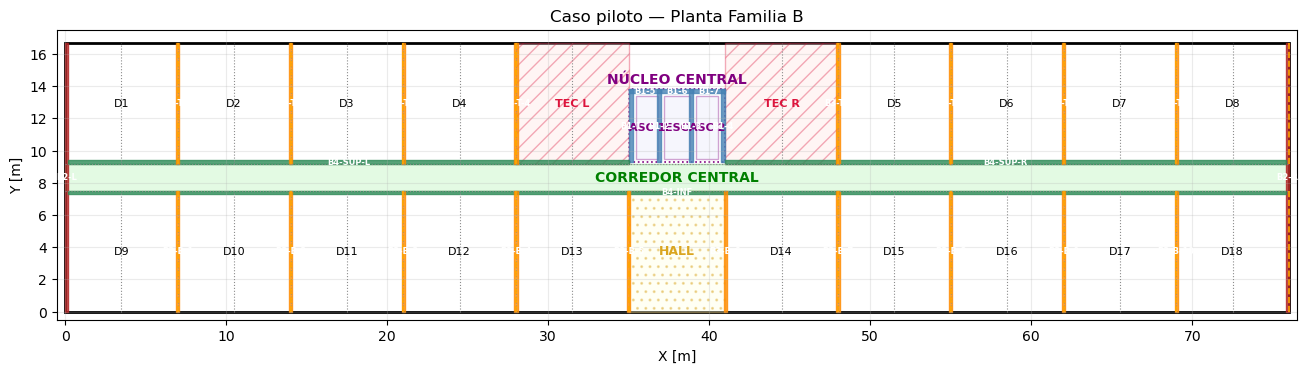

In [4]:
# ============================================================
# CELDA 4 — VISUALIZAR PLANTA DEL CASO PILOTO
# ============================================================
fig, ax = plt.subplots(figsize=(16, 7))

try:
    plot_family_B_plan(
        geom_piloto,
        params_piloto,
        ax=ax,
        show_labels=True,
        cfg=FAMILIA_B_CFG
    )
except TypeError:
    # Compatibilidad si el CORE exportado aún tiene la firma antigua sin cfg.
    familia_core.FAMILIA_B_CFG = FAMILIA_B_CFG
    plot_family_B_plan(
        geom_piloto,
        params_piloto,
        ax=ax,
        show_labels=True
    )

ax.set_title("Caso piloto — Planta Familia B")
plt.show()


## Explicación

Aquí se revisa visualmente:

- núcleo
- hall frontal
- zonas técnicas laterales
- muros extremos
- medianeros
- muros longitudinales del pasillo
- departamentos

Esta es la primera auditoría manual antes de confiar en el modelo dinámico.


## 🧱 Hito — Geometría → tabla estructural de muros

`geometry_to_wall_df` transforma la lista de muros del diccionario `geom` en un **DataFrame estructural** (`wall_df`), una fila por muro con su grupo, orientación, posición, dimensiones, **largo y espesor efectivos**, área en planta y centroide $(c_x, c_y)$. Esta tabla es el insumo directo del cálculo de rigidez y de las auditorías.

**Se obtiene:** `wall_df_piloto`, la representación tabular de los muros (con su conteo por grupo y orientación) que alimenta el resto del análisis.

In [5]:
# ============================================================
# CELDA 5 — CONVERTIR GEOMETRÍA A TABLA DE MUROS
# ============================================================
def geometry_to_wall_df(geom, params):
    rows = []
    for idx, w in enumerate(geom["walls"]):
        group = w.get("group", "NA")
        orient = w.get("orientation", "NA")

        wx = float(w["w"])
        wy = float(w["h"])

        if orient == "X":
            length = wx
            thickness = wy
        elif orient == "Y":
            length = wy
            thickness = wx
        else:
            length = max(wx, wy)
            thickness = min(wx, wy)

        rows.append({
            "wall_id": idx,
            "label": w.get("label", f"W{idx}"),
            "group": group,
            "orientation": orient,
            "x": float(w["x"]),
            "y": float(w["y"]),
            "w": wx,
            "h": wy,
            "length_m": float(length),
            "thickness_m": float(thickness),
            "area_plan_m2": float(wx * wy),
            "cx": float(w["x"] + 0.5 * wx),
            "cy": float(w["y"] + 0.5 * wy),
        })

    return pd.DataFrame(rows)

wall_df_piloto = geometry_to_wall_df(geom_piloto, params_piloto)

print("="*90)
print("TABLA DE MUROS — CASO PILOTO")
print("="*90)
display(wall_df_piloto)

print("="*90)
print("CONTEO POR GRUPO Y ORIENTACIÓN")
print("="*90)
display(wall_df_piloto.groupby(["group", "orientation"]).size().reset_index(name="n_muros"))


TABLA DE MUROS — CASO PILOTO


,wall_id,label,group,orientation,x,y,w,h,length_m,thickness_m,area_plan_m2,cx,cy
0,0,B1-1,B1,NA,35.00,9.30,0.25,4.50,4.5,0.25,1.125,35.125,11.550
1,1,B1-2,B1,NA,36.75,9.30,0.25,4.50,4.5,0.25,1.125,36.875,11.550
2,2,B1-3,B1,NA,38.75,9.30,0.25,4.50,4.5,0.25,1.125,38.875,11.550
3,3,B1-4,B1,NA,40.75,9.30,0.25,4.50,4.5,0.25,1.125,40.875,11.550
4,4,B1-5,B1,NA,35.00,13.55,2.00,0.25,2.0,0.25,0.500,36.000,13.675
5,5,B1-6,B1,NA,37.00,13.55,2.00,0.25,2.0,0.25,0.500,38.000,13.675
6,6,B1-7,B1,NA,39.00,13.55,2.00,0.25,2.0,0.25,0.500,40.000,13.675
7,7,B2-L,B2,NA,0.00,0.00,0.20,16.70,16.7,0.20,3.340,0.100,8.350
8,8,B2-R,B2,NA,75.80,0.00,0.20,16.70,16.7,0.20,3.340,75.900,8.350
9,9,B4-SUP-L,B4,NA,0.20,9.20,34.80,0.20,34.8,0.20,6.960,17.600,9.300


CONTEO POR GRUPO Y ORIENTACIÓN


,group,orientation,n_muros
0,B1,NA,7
1,B2,NA,2
2,B3,NA,18
3,B4,NA,3


## 🔍 Hito — Auditoría geométrico-estructural

`audit_wall_geometry` aplica un conjunto de chequeos booleanos sobre la tabla de muros: existencia de los cuatro grupos (B1–B4), tamaños positivos, muros dentro de la planta, muros de extremo B2 que recorren todo $L_y$, medianeros B3 con orientación vertical, un mínimo de muros B4, y la **densidad planimétrica de muros**. El veredicto global queda en `geometry_pass`.

**Se obtiene:** el diccionario de chequeos del piloto, que actúa como **filtro de validez geométrica** antes de pasar al modelo dinámico.

In [6]:
# ============================================================
# CELDA 6 — AUDITORÍA GEOMÉTRICA-ESTRUCTURAL
# ============================================================
def audit_wall_geometry(params, geom, wall_df, tol=1e-9):
    Lx = params["Lx_m"]
    Ly = params["Ly_m"]

    checks = {}

    # --------------------------------------------------------
    # Existencia básica
    # --------------------------------------------------------
    checks["n_walls_total"] = len(wall_df)

    checks["has_B1"] = bool((wall_df["group"] == "B1").any())
    checks["has_B2"] = bool((wall_df["group"] == "B2").any())
    checks["has_B3"] = bool((wall_df["group"] == "B3").any())
    checks["has_B4"] = bool((wall_df["group"] == "B4").any())

    # --------------------------------------------------------
    # Tamaños positivos
    # --------------------------------------------------------
    checks["all_walls_positive_size"] = bool(
        ((wall_df["w"] > tol) & (wall_df["h"] > tol)).all()
    )

    # --------------------------------------------------------
    # Dentro de planta
    # --------------------------------------------------------
    inside_x = (
        (wall_df["x"] >= -tol) &
        (wall_df["x"] + wall_df["w"] <= Lx + tol)
    )

    inside_y = (
        (wall_df["y"] >= -tol) &
        (wall_df["y"] + wall_df["h"] <= Ly + tol)
    )

    checks["all_walls_inside_plan"] = bool((inside_x & inside_y).all())

    # --------------------------------------------------------
    # B2 extremos recorren altura total planta
    # --------------------------------------------------------
    b2 = wall_df[wall_df["group"] == "B2"]

    checks["B2_full_height_ok"] = bool(
        len(b2) == 0 or
        (np.isclose(b2["h"], Ly, atol=1e-6)).all()
    )

    # --------------------------------------------------------
    # B3 deben ser verticales geométricamente
    # --------------------------------------------------------
    b3 = wall_df[wall_df["group"] == "B3"]

    checks["B3_vertical_ok"] = bool(
        len(b3) == 0 or
        (b3["h"] > b3["w"]).all()
    )

    # --------------------------------------------------------
    # B4 cantidad mínima
    # --------------------------------------------------------
    b4 = wall_df[wall_df["group"] == "B4"]

    checks["B4_count_ok"] = bool(len(b4) >= 3)

    # --------------------------------------------------------
    # Densidad de muros
    # --------------------------------------------------------
    checks["wall_density_plan"] = float(
        wall_df["area_plan_m2"].sum() / params["A_geom_m2"]
    )

    # --------------------------------------------------------
    # Resultado global booleano
    # --------------------------------------------------------
    checks["geometry_pass"] = bool(
        checks["has_B1"] and
        checks["has_B2"] and
        checks["has_B3"] and
        checks["has_B4"] and
        checks["all_walls_positive_size"] and
        checks["all_walls_inside_plan"] and
        checks["B2_full_height_ok"] and
        checks["B3_vertical_ok"] and
        checks["B4_count_ok"]
    )

    return checks


checks_piloto = audit_wall_geometry(
    params_piloto,
    geom_piloto,
    wall_df_piloto
)

print("="*90)
print("AUDITORÍA GEOMÉTRICA-ESTRUCTURAL — CASO PILOTO")
print("="*90)

for k, v in checks_piloto.items():
    print(f"{k:30s}: {v}")

AUDITORÍA GEOMÉTRICA-ESTRUCTURAL — CASO PILOTO
n_walls_total                 : 30
has_B1                        : True
has_B2                        : True
has_B3                        : True
has_B4                        : True
all_walls_positive_size       : True
all_walls_inside_plan         : True
B2_full_height_ok             : True
B3_vertical_ok                : True
B4_count_ok                   : True
wall_density_plan             : 0.05414434289316104
geometry_pass                 : True


## ⚖️ Hito — Masa sísmica por piso

`compute_floor_masses` estima el peso sísmico de cada nivel como $W = A\,(g_k + \psi\,q_k)$, usando la carga viva y el factor de combinación ψ definidos en la familia. El **último nivel (cubierta)** se trata aparte ($\psi = 0$ para la sobrecarga), y los pesos se convierten a masa dividiendo por $g$. Devuelve el vector de masas por piso y los totales.

**Se obtiene:** `floor_masses_piloto` y la masa/peso totales — el insumo que poblará la matriz de masa $M$ del modelo modal.

MASA SÍSMICA — CASO PILOTO
W_floor tipo      = 9,519.00 kN
W_roof cubierta   = 8,884.40 kN
W_total sísmico   = 94,555.40 kN
------------------------------------------------------------------------------------------
m_floor tipo      = 970,667.86 kg
m_roof cubierta   = 905,956.67 kg
M_total           = 9,641,967.44 kg
------------------------------------------------------------------------------------------
Factor cubierta / piso tipo = 0.933
MASA POR NIVEL
Piso 01 | PISO TIPO                | masa = 970,667.86 kg
Piso 02 | PISO TIPO                | masa = 970,667.86 kg
Piso 03 | PISO TIPO                | masa = 970,667.86 kg
Piso 04 | PISO TIPO                | masa = 970,667.86 kg
Piso 05 | PISO TIPO                | masa = 970,667.86 kg
Piso 06 | PISO TIPO                | masa = 970,667.86 kg
Piso 07 | PISO TIPO                | masa = 970,667.86 kg
Piso 08 | PISO TIPO                | masa = 970,667.86 kg
Piso 09 | PISO TIPO                | masa = 970,667.86 kg
Piso 10 | CUBIERT

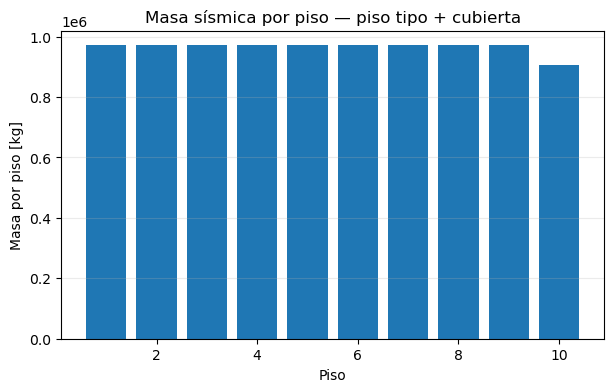

In [7]:
# ============================================================
# CELDA 7 — MASA SÍSMICA POR PISO
# Piso tipo + cubierta en último nivel
# ============================================================
def compute_floor_masses(params):
    A = params["A_geom_m2"]
    gk = params["gk_kN_m2"]

    qk = FAMILIA_B_CFG["fixed"].get("qk_default_kN_m2", 2.0)
    psi_floor = FAMILIA_B_CFG["fixed"].get("psi_default", 0.25)

    # Para cubierta: se considera carga permanente,
    # pero se omite la sobrecarga de uso en el peso sísmico global.
    psi_roof = 0.0

    # Peso sísmico piso tipo [kN]
    W_floor_kN = A * (gk + psi_floor * qk)

    # Peso sísmico cubierta / último nivel [kN]
    W_roof_kN = A * (gk + psi_roof * qk)

    # Conversión a masa [kg]
    m_floor_kg = W_floor_kN * 1000.0 / G_ACCEL
    m_roof_kg  = W_roof_kN  * 1000.0 / G_ACCEL

    N = int(params["N_pisos"])

    masses = np.full(N, m_floor_kg, dtype=float)
    masses[-1] = m_roof_kg

    M_total_kg = masses.sum()
    W_total_kN = (N - 1) * W_floor_kN + W_roof_kN

    return masses, M_total_kg, W_floor_kN, W_roof_kN, W_total_kN


floor_masses_piloto, M_total_piloto, W_floor_kN_piloto, W_roof_kN_piloto, W_total_kN_piloto = compute_floor_masses(params_piloto)

print("="*90)
print("MASA SÍSMICA — CASO PILOTO")
print("="*90)
print(f"W_floor tipo      = {W_floor_kN_piloto:,.2f} kN")
print(f"W_roof cubierta   = {W_roof_kN_piloto:,.2f} kN")
print(f"W_total sísmico   = {W_total_kN_piloto:,.2f} kN")
print("-"*90)
print(f"m_floor tipo      = {floor_masses_piloto[0]:,.2f} kg")
print(f"m_roof cubierta   = {floor_masses_piloto[-1]:,.2f} kg")
print(f"M_total           = {M_total_piloto:,.2f} kg")
print("-"*90)
print(f"Factor cubierta / piso tipo = {floor_masses_piloto[-1] / floor_masses_piloto[0]:.3f}")

print("="*90)
print("MASA POR NIVEL")
print("="*90)

for i, m in enumerate(floor_masses_piloto, start=1):
    tipo = "CUBIERTA / ÚLTIMO NIVEL" if i == len(floor_masses_piloto) else "PISO TIPO"
    print(f"Piso {i:02d} | {tipo:24s} | masa = {m:,.2f} kg")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(np.arange(1, params_piloto["N_pisos"] + 1), floor_masses_piloto)
ax.set_xlabel("Piso")
ax.set_ylabel("Masa por piso [kg]")
ax.set_title("Masa sísmica por piso — piso tipo + cubierta")
ax.grid(axis="y", alpha=0.25)
plt.show()

## Explicación

La masa sísmica por piso se estima mediante:

$$
W_i=A_{planta}(g_k+\psi q_k)
$$

y:

$$
m_i=\frac{W_i}{g}
$$

Para el grado rotacional se usa:

$$
I_z=m_i\frac{L_x^2+L_y^2}{12}
$$


In [8]:
# ============================================================
# CELDA 8 — MATRICES M Y K
# RIGIDEZ DIRECCIONAL + B4 DISCRETIZADO CON DESCUENTOS
# ============================================================
def concrete_E_Pa(params):
    return float(params["E_MPa"]) * 1e6


# Parámetros de idealización estructural para auditoría modal
NU_CONC = 0.20
ETA_CRACKED_WALL = 0.35   # rigidez efectiva fisurada de muros HA
KAPPA_SHEAR = 1.20        # factor aproximado de corte

# Descuentos arquitectónicos en muros B4
OPENING_DEPT_M = 0.90     # acceso a departamento
OPENING_TECH_M = 0.90     # acceso a zona técnica
OPENING_HALL_M = 1.40     # acceso hall/núcleo


def split_x_wall_with_openings(
    wall,
    params,
    opening_dept_m=OPENING_DEPT_M,
    opening_tech_m=OPENING_TECH_M,
    opening_hall_m=OPENING_HALL_M,
):
    """
    Divide un muro B4 longitudinal en paños estructurales reales.

    No se usa un largo ficticio. Se toma el tramo geométrico real y se
    discretiza por bahías de departamento, descontando aberturas asociadas a:
    - accesos de departamentos,
    - accesos a zonas técnicas,
    - acceso al hall/núcleo.

    La idea estructural es evitar que un B4 muy largo se interprete como un
    único muro monolítico cuya inercia crece artificialmente con L^3.
    """
    x0 = float(wall["x"])
    x1 = float(wall["x"] + wall["w"])
    y  = float(wall["y"])
    t  = float(wall["h"])

    L_mod = float(params["L_mod_m"])
    mods_por_depto = int(params["mods_por_depto"])
    dept_w = mods_por_depto * L_mod

    x_nuc_0 = params["n_mod_izq"] * L_mod
    x_nuc_1 = x_nuc_0 + params["L_nucleo_m"]

    segments = []
    current = x0
    idx = 1

    while current < x1 - 1e-9:
        bay_start = current
        bay_end = min(current + dept_w, x1)
        bay_len = bay_end - bay_start

        if bay_len <= 0.30:
            break

        bay_mid = 0.5 * (bay_start + bay_end)

        # Determinar abertura representativa de la bahía
        if (
            (bay_start <= x_nuc_0 <= bay_end)
            or (bay_start <= x_nuc_1 <= bay_end)
            or (x_nuc_0 <= bay_mid <= x_nuc_1)
        ):
            opening = opening_hall_m
            use_type = "hall"
        elif abs(bay_end - x_nuc_0) < 1e-6 or abs(bay_start - x_nuc_1) < 1e-6:
            opening = opening_tech_m
            use_type = "tecnico"
        else:
            opening = opening_dept_m
            use_type = "depto"

        # No permitir que la abertura elimine casi toda la bahía
        opening = min(opening, 0.60 * bay_len)
        solid_total = bay_len - opening

        if solid_total > 0.40:
            # Se reparte el sólido remanente a ambos lados de la abertura
            solid_each = 0.5 * solid_total

            pieces = [
                (bay_start, solid_each, "L"),
                (bay_end - solid_each, solid_each, "R"),
            ]

            for sx, sw, side in pieces:
                if sw > 0.20:
                    new_wall = dict(wall)
                    new_wall["x"] = float(sx)
                    new_wall["y"] = float(y)
                    new_wall["w"] = float(sw)
                    new_wall["h"] = float(t)
                    new_wall["length_m"] = float(sw)
                    new_wall["thickness_m"] = float(t)
                    new_wall["area_plan_m2"] = float(sw * t)
                    new_wall["cx"] = float(sx + 0.5 * sw)
                    new_wall["cy"] = float(y + 0.5 * t)
                    new_wall["orientation"] = "X"
                    new_wall["label"] = f'{wall["label"]}-{idx}-{use_type}-{side}'
                    new_wall["original_label"] = wall["label"]
                    new_wall["opening_type"] = use_type
                    segments.append(new_wall)

            idx += 1

        current = bay_end

    return segments


def expand_B4_walls_with_openings(wall_df, params):
    """
    Reemplaza muros B4 continuos por paños B4 discretizados.
    Los demás grupos se conservan sin modificación geométrica.
    """
    rows = []

    for _, row in wall_df.iterrows():
        wall = row.to_dict()

        if wall.get("group") == "B4" and float(wall["w"]) >= float(wall["h"]):
            rows.extend(split_x_wall_with_openings(wall, params))
        else:
            rows.append(wall)

    return pd.DataFrame(rows)


def wall_directional_stiffness(wall, params):
    """
    Calcula kx, ky y ktheta de un muro considerando su orientación real.

    Convención:
    - Muro orientado en X: fuerte frente a movimiento Y y débil frente a X.
    - Muro orientado en Y: fuerte frente a movimiento X y débil frente a Y.

    Se usa una rigidez flexión+corte en serie para evitar rigideces excesivas.
    """
    E = concrete_E_Pa(params)
    Eeff = ETA_CRACKED_WALL * E
    G = Eeff / (2.0 * (1.0 + NU_CONC))

    h_story = float(params["h_story_m"])

    w = float(wall["w"])
    h = float(wall["h"])

    # Identificación robusta de orientación
    if wall.get("orientation", None) in ("X", "Y"):
        orientation = wall["orientation"]
    else:
        orientation = "X" if w >= h else "Y"

    if orientation == "X":
        L = max(w, 0.20)
        t = max(h, 0.10)
    else:
        L = max(h, 0.20)
        t = max(w, 0.10)

    # Inercias fuerte y débil en planta
    I_fuerte = t * L**3 / 12.0
    I_debil  = L * t**3 / 12.0
    A_shear  = t * L

    def k_wall(I):
        # Flexión + corte en serie
        flex = h_story**3 / (12.0 * Eeff * I)
        shear = KAPPA_SHEAR * h_story / (G * A_shear)
        return 1.0 / (flex + shear)

    k_fuerte = k_wall(I_fuerte)
    k_debil  = k_wall(I_debil)

    if orientation == "X":
        kx = k_debil
        ky = k_fuerte
    else:
        kx = k_fuerte
        ky = k_debil

    cx = float(wall["x"] + 0.5 * wall["w"])
    cy = float(wall["y"] + 0.5 * wall["h"])

    x_cm = float(params["Lx_m"]) / 2.0
    y_cm = float(params["Ly_m"]) / 2.0

    ktheta = kx * (cy - y_cm)**2 + ky * (cx - x_cm)**2

    return {
        "wall_id": wall.get("wall_id", np.nan),
        "label": wall.get("label", ""),
        "group": wall.get("group", ""),
        "orientation": orientation,
        "L_eff_m": L,
        "t_eff_m": t,
        "kx_i": kx,
        "ky_i": ky,
        "ktheta_i": ktheta,
        "cx": cx,
        "cy": cy,
    }


def compute_story_stiffness_from_walls(params, wall_df):
    """
    Calcula la rigidez equivalente por piso.

    Correcciones incorporadas:
    1. B4 se discretiza por paños con descuentos por accesos.
    2. La rigidez distingue dirección fuerte y débil.
    3. Kx y Ky ya no se calculan como si todos los muros fueran isotrópicos.
    """
    wall_df_struct = expand_B4_walls_with_openings(wall_df, params)

    rows = []
    for _, wall in wall_df_struct.iterrows():
        rows.append(wall_directional_stiffness(wall, params))

    stiff_df = pd.DataFrame(rows)

    Kx_story = float(stiff_df["kx_i"].sum())
    Ky_story = float(stiff_df["ky_i"].sum())
    Ktheta_story = float(stiff_df["ktheta_i"].sum())

    return {
        "Kx_story": Kx_story,
        "Ky_story": Ky_story,
        "Ktheta_story": Ktheta_story,
        "stiff_df": stiff_df,
        "wall_df_struct": wall_df_struct,
    }


def assemble_shear_building_matrices(params, floor_masses, stiff):
    """
    Ensambla matrices reducidas de edificio tipo corte con 3 GDL por piso:
    Ux, Uy y theta_z.

    Usa las rigideces corregidas:
    - Kx_story
    - Ky_story
    - Ktheta_story
    """
    N = int(params["N_pisos"])
    D = 3 * N

    Lx = params["Lx_m"]
    Ly = params["Ly_m"]

    M = np.zeros((D, D), dtype=float)
    K = np.zeros((D, D), dtype=float)

    Kstory = np.array([
        stiff["Kx_story"],
        stiff["Ky_story"],
        stiff["Ktheta_story"],
    ], dtype=float)

    for i in range(N):
        m = floor_masses[i]
        Iz = m * (Lx**2 + Ly**2) / 12.0

        M[3*i + 0, 3*i + 0] = m
        M[3*i + 1, 3*i + 1] = m
        M[3*i + 2, 3*i + 2] = Iz

    for story in range(N):
        for d in range(3):
            k = Kstory[d]
            idx_top = 3*story + d

            if story == 0:
                K[idx_top, idx_top] += k
            else:
                idx_bot = 3*(story-1) + d
                K[idx_top, idx_top] += k
                K[idx_bot, idx_bot] += k
                K[idx_top, idx_bot] -= k
                K[idx_bot, idx_top] -= k

    return M, K


# Aplicación al caso piloto
stiff_piloto = compute_story_stiffness_from_walls(params_piloto, wall_df_piloto)
M_piloto, K_piloto = assemble_shear_building_matrices(
    params_piloto,
    floor_masses_piloto,
    stiff_piloto
)

print("="*90)
print("RIGIDEZ EQUIVALENTE CORREGIDA — CASO PILOTO")
print("="*90)

Kx_story = stiff_piloto["Kx_story"]
Ky_story = stiff_piloto["Ky_story"]
Ktheta_story = stiff_piloto["Ktheta_story"]

ratio_Kx_Ky = Kx_story / Ky_story if Ky_story > 0 else np.nan
ratio_Ky_Kx = Ky_story / Kx_story if Kx_story > 0 else np.nan

print(f"Kx_story      = {Kx_story:,.3e} N/m")
print(f"Ky_story      = {Ky_story:,.3e} N/m")
print(f"Ktheta_story  = {Ktheta_story:,.3e} N·m/rad")
print("-"*90)
print(f"Kx / Ky       = {ratio_Kx_Ky:.3f}")
print(f"Ky / Kx       = {ratio_Ky_Kx:.3f}")
print("-"*90)
print(f"Muros originales     = {len(wall_df_piloto)}")
print(f"Muros estructurales  = {len(stiff_piloto['wall_df_struct'])}")
print(f"M_shape = {M_piloto.shape}")
print(f"K_shape = {K_piloto.shape}")

print("\nDirección más rígida:", "X" if Kx_story > Ky_story else "Y")

print("="*90)
print("RIGIDEZ POR GRUPO — Kx vs Ky")
print("="*90)

rigidez_grupos = (
    stiff_piloto["stiff_df"]
    .groupby("group")[["kx_i", "ky_i", "ktheta_i"]]
    .sum()
    .reset_index()
)

rigidez_grupos["Kx/Ky"] = rigidez_grupos["kx_i"] / rigidez_grupos["ky_i"]
rigidez_grupos["Ky/Kx"] = rigidez_grupos["ky_i"] / rigidez_grupos["kx_i"]

display(rigidez_grupos)

print("="*90)
print("RESUMEN INTERPRETATIVO")
print("="*90)

for _, row in rigidez_grupos.iterrows():
    g = row["group"]
    kx = row["kx_i"]
    ky = row["ky_i"]

    if kx > 3 * ky:
        msg = "aporta principalmente en X"
    elif ky > 3 * kx:
        msg = "aporta principalmente en Y"
    else:
        msg = "aporte mixto / relativamente balanceado"

    print(f"{g}: Kx = {kx:,.3e} | Ky = {ky:,.3e} → {msg}")

print("="*90)
print("DETALLE B4 DISCRETIZADO")
print("="*90)
display(
    stiff_piloto["wall_df_struct"]
    .loc[lambda df: df["group"] == "B4", ["label", "x", "y", "w", "h", "group"]]
    .reset_index(drop=True)
)


RIGIDEZ EQUIVALENTE CORREGIDA — CASO PILOTO
Kx_story      = 4.273e+10 N/m
Ky_story      = 2.414e+10 N/m
Ktheta_story  = 1.228e+13 N·m/rad
------------------------------------------------------------------------------------------
Kx / Ky       = 1.770
Ky / Kx       = 0.565
------------------------------------------------------------------------------------------
Muros originales     = 30
Muros estructurales  = 69
M_shape = (30, 30)
K_shape = (30, 30)

Dirección más rígida: X
RIGIDEZ POR GRUPO — Kx vs Ky


,group,kx_i,ky_i,ktheta_i,Kx/Ky,Ky/Kx
0,B1,4.676673e+09,1.190092e+09,5.206941e+10,3.929674,0.254474
1,B2,7.670484e+09,1.204100e+08,1.729581e+11,63.703071,0.015698
2,B3,2.993765e+10,4.866870e+08,8.422695e+11,61.513158,0.016257
3,B4,4.481125e+08,2.234652e+10,1.121001e+13,0.020053,49.868096


RESUMEN INTERPRETATIVO
B1: Kx = 4.677e+09 | Ky = 1.190e+09 → aporta principalmente en X
B2: Kx = 7.670e+09 | Ky = 1.204e+08 → aporta principalmente en X
B3: Kx = 2.994e+10 | Ky = 4.867e+08 → aporta principalmente en X
B4: Kx = 4.481e+08 | Ky = 2.235e+10 → aporta principalmente en Y
DETALLE B4 DISCRETIZADO


,label,x,y,w,h,group
0,B4-SUP-L-1-depto-L,0.20,9.2,3.05,0.2,B4
1,B4-SUP-L-1-depto-R,4.15,9.2,3.05,0.2,B4
2,B4-SUP-L-2-depto-L,7.20,9.2,3.05,0.2,B4
3,B4-SUP-L-2-depto-R,11.15,9.2,3.05,0.2,B4
4,B4-SUP-L-3-depto-L,14.20,9.2,3.05,0.2,B4
5,B4-SUP-L-3-depto-R,18.15,9.2,3.05,0.2,B4
6,B4-SUP-L-4-depto-L,21.20,9.2,3.05,0.2,B4
7,B4-SUP-L-4-depto-R,25.15,9.2,3.05,0.2,B4
8,B4-SUP-L-5-hall-L,28.20,9.2,2.70,0.2,B4
9,B4-SUP-L-5-hall-R,32.30,9.2,2.70,0.2,B4


## Explicación

Se arma un modelo reducido tipo edificio de corte con 3 GDL por piso:

$$
\{U_x,U_y,\theta_z\}
$$

La rigidez lateral se obtiene desde los muros, pero con dos correcciones importantes:

1. **Rigidez direccional:** un muro orientado en X no aporta igual rigidez en X e Y.  
   - Muro orientado en X: fuerte frente a desplazamiento Y.
   - Muro orientado en Y: fuerte frente a desplazamiento X.

2. **B4 discretizado:** los muros longitudinales de pasillo no se interpretan como un único muro continuo de gran longitud. Se discretizan en paños estructurales, descontando accesos a departamentos, hall y zonas técnicas.

Esto evita que la rigidez crezca artificialmente como:

$$
I \propto L^3
$$

para un muro de pasillo excesivamente largo.

La ecuación modal que se resolverá después es:

$$
K\phi_r=\omega_r^2 M\phi_r
$$


In [9]:
# ============================================================
# CELDA 9 — SOLVER MODAL
# ============================================================
def solve_modal_matrices(M, K, n_modes=None):
    if not SCIPY_AVAILABLE:
        raise RuntimeError("scipy.linalg.eigh no está disponible.")

    D = M.shape[0]
    if n_modes is None:
        n_modes = D
    n_modes = min(n_modes, D)

    vals, vecs = eigh(K, M)

    idx = np.argsort(vals)
    vals = np.real(vals[idx])
    vecs = np.real(vecs[:, idx])

    pos = vals > 1e-10
    vals = vals[pos]
    vecs = vecs[:, pos]

    vals = vals[:n_modes]
    vecs = vecs[:, :n_modes]

    omegas = np.sqrt(vals)
    periods = 2*np.pi/omegas

    Phi = vecs.copy()
    for r in range(Phi.shape[1]):
        mr = Phi[:, r].T @ M @ Phi[:, r]
        Phi[:, r] /= np.sqrt(abs(mr))

    return {
        "lambdas": vals,
        "omegas": omegas,
        "T": periods,
        "Phi": Phi,
    }

modal_piloto = solve_modal_matrices(M_piloto, K_piloto, n_modes=min(N_MODOS_MAX, 3*params_piloto["N_pisos"]))

modal_df_piloto = pd.DataFrame({
    "modo": np.arange(1, len(modal_piloto["T"]) + 1),
    "lambda": modal_piloto["lambdas"],
    "omega_rad_s": modal_piloto["omegas"],
    "T_s": modal_piloto["T"],
})

display(modal_df_piloto.head(12))


,modo,lambda,omega_rad_s,T_s
0,1,562.716278,23.721642,0.264871
1,2,567.105159,23.813970,0.263845
2,3,995.974259,31.559060,0.199093
3,4,4986.825093,70.617456,0.088975
4,5,5025.719614,70.892310,0.088630
5,6,8826.383059,93.948832,0.066879
6,7,13429.515257,115.885785,0.054219
7,8,13534.258167,116.336831,0.054009
8,9,23769.441227,154.173413,0.040754
9,10,25119.347367,158.490843,0.039644


## Explicación

El problema modal se resuelve como:

$$
K\phi_r=\lambda_rM\phi_r
$$

con:

$$
\lambda_r=\omega_r^2
$$

y:

$$
T_r=\frac{2\pi}{\omega_r}
$$

Los modos se normalizan por masa:

$$
\phi_r^TM\phi_r=1
$$


In [10]:
# ============================================================
# CELDA 10 — MASA EFECTIVA
# ============================================================
def modal_participation_effective_mass(M, Phi, params):
    N = int(params["N_pisos"])
    D = 3*N
    Kmod = Phi.shape[1]

    rx = np.zeros(D)
    ry = np.zeros(D)
    rz = np.zeros(D)

    for i in range(N):
        rx[3*i + 0] = 1.0
        ry[3*i + 1] = 1.0
        rz[3*i + 2] = 1.0

    dirs = {"x": rx, "y": ry, "rz": rz}
    out = {}

    for name, rvec in dirs.items():
        denom_total = rvec.T @ M @ rvec
        Gamma = np.zeros(Kmod)
        meff = np.zeros(Kmod)

        for j in range(Kmod):
            phi = Phi[:, j]
            denom = phi.T @ M @ phi
            num = phi.T @ M @ rvec
            Gamma[j] = num / denom
            meff[j] = (num**2) / (denom * denom_total)

        out[f"Gamma_{name}"] = Gamma
        out[f"mass_part_{name}"] = meff
        out[f"mass_acc_{name}"] = np.cumsum(meff)

    return out

def first_mode_reaching_mass(mass_acc, target=0.90):
    idx = np.where(mass_acc >= target)[0]
    return None if len(idx) == 0 else int(idx[0] + 1)

part_piloto = modal_participation_effective_mass(M_piloto, modal_piloto["Phi"], params_piloto)

modal_table_piloto = pd.DataFrame({
    "modo": np.arange(1, len(modal_piloto["T"]) + 1),
    "T_s": modal_piloto["T"],
    "mass_x": part_piloto["mass_part_x"],
    "acc_x": part_piloto["mass_acc_x"],
    "mass_y": part_piloto["mass_part_y"],
    "acc_y": part_piloto["mass_acc_y"],
    "mass_rz": part_piloto["mass_part_rz"],
    "acc_rz": part_piloto["mass_acc_rz"],
})

n90_x = first_mode_reaching_mass(part_piloto["mass_acc_x"])
n90_y = first_mode_reaching_mass(part_piloto["mass_acc_y"])

print("n90_x:", n90_x)
print("n90_y:", n90_y)
display(modal_table_piloto.head(18))


n90_x: 6
n90_y: 4


,modo,T_s,mass_x,acc_x,mass_y,acc_y,mass_rz,acc_rz
0,1,0.264871,2.489608e-31,2.489608e-31,8.481390e-01,0.848139,2.199069e-24,2.199069e-24
1,2,0.263845,1.925617e-29,1.950513e-29,2.198786e-24,0.848139,8.481390e-01,8.481390e-01
2,3,0.199093,8.481390e-01,8.481390e-01,3.362078e-31,0.848139,3.442046e-29,8.481390e-01
3,4,0.088975,5.058971e-31,8.481390e-01,9.138207e-02,0.939521,1.820447e-27,8.481390e-01
4,5,0.088630,1.833624e-29,8.481390e-01,1.856181e-27,0.939521,9.138207e-02,9.395211e-01
5,6,0.066879,9.138207e-02,9.395211e-01,1.077851e-32,0.939521,8.787205e-33,9.395211e-01
6,7,0.054219,3.402233e-32,9.395211e-01,3.087343e-02,0.970395,6.679280e-29,9.395211e-01
7,8,0.054009,9.291329e-34,9.395211e-01,7.120994e-29,0.970395,3.087343e-02,9.703945e-01
8,9,0.040754,3.087343e-02,9.703945e-01,1.309549e-33,0.970395,3.886665e-33,9.703945e-01
9,10,0.039644,8.709008e-31,9.703945e-01,1.424479e-02,0.984639,3.287551e-30,9.703945e-01


## Explicación

La participación modal se calcula como:

$$
\Gamma_r^{(c)}=
\frac{\phi_r^TMr^{(c)}}{\phi_r^TM\phi_r}
$$

La fracción de masa efectiva modal es:

$$
m_{eff,r}^{(c)}=
\frac{(\phi_r^TMr^{(c)})^2}{(\phi_r^TM\phi_r)(r^{(c)T}Mr^{(c)})}
$$

La acumulada es:

$$
M_{acc}^{(c)}(r)=\sum_{j=1}^{r}m_{eff,j}^{(c)}
$$

El criterio a auditar es:

$$
M_{acc}^{(c)}(r)\geq 0.90
$$


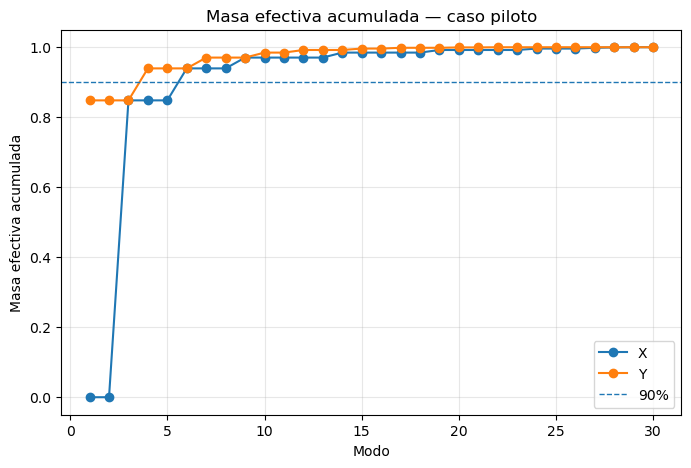

In [11]:
# ============================================================
# CELDA 11 — GRÁFICO DE MASA EFECTIVA ACUMULADA
# ============================================================
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(modal_table_piloto["modo"], modal_table_piloto["acc_x"], marker="o", label="X")
ax.plot(modal_table_piloto["modo"], modal_table_piloto["acc_y"], marker="o", label="Y")
ax.axhline(0.90, linestyle="--", linewidth=1, label="90%")
ax.set_xlabel("Modo")
ax.set_ylabel("Masa efectiva acumulada")
ax.set_title("Masa efectiva acumulada — caso piloto")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


## Explicación

Este gráfico muestra cuántos modos se requieren para alcanzar el 90% en X e Y.

Si no se alcanza el 90%, se debe aumentar \(K_{max}\) o revisar el modelo.


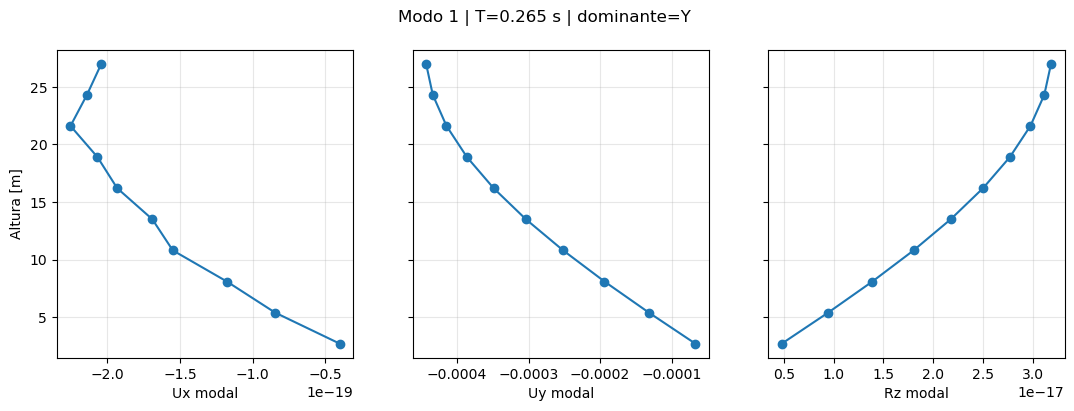

Modo 1: dominante=Y, masas={'X': np.float64(2.4896075351818257e-31), 'Y': np.float64(0.8481390201103871), 'Rz': np.float64(2.199069438044942e-24)}


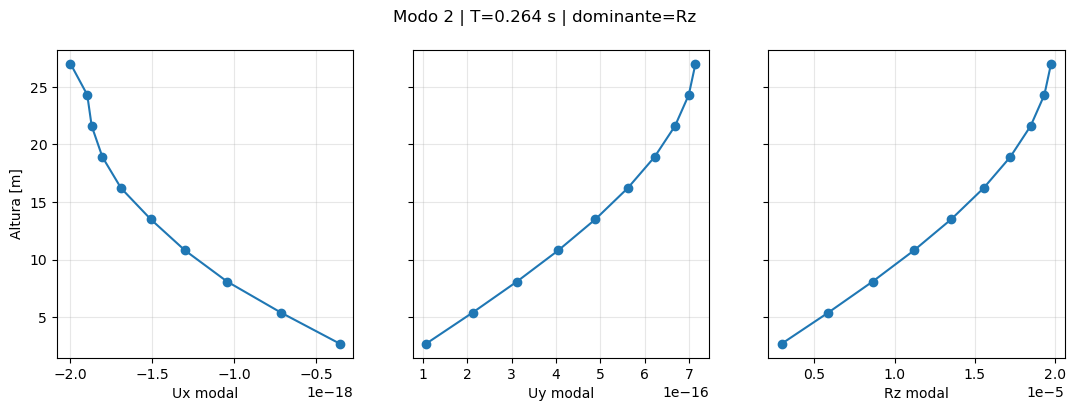

Modo 2: dominante=Rz, masas={'X': np.float64(1.9256168135632795e-29), 'Y': np.float64(2.1987858213678686e-24), 'Rz': np.float64(0.848139020110387)}


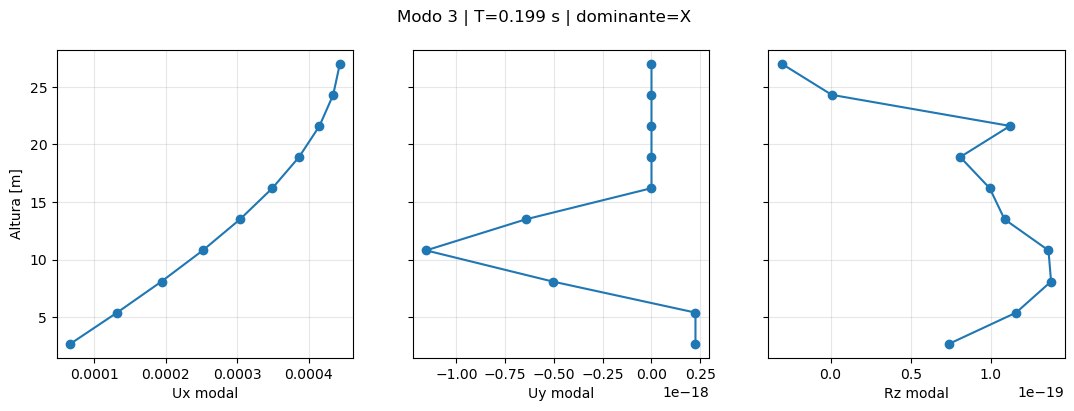

Modo 3: dominante=X, masas={'X': np.float64(0.8481390201103877), 'Y': np.float64(3.3620782893316076e-31), 'Rz': np.float64(3.442046123983724e-29)}


In [12]:
# ============================================================
# CELDA 12 — FORMAS MODALES POR PISO
# ============================================================
def extract_floor_components(Phi, params, mode_index):
    N = int(params["N_pisos"])
    phi = Phi[:, mode_index]
    ux = np.array([phi[3*i + 0] for i in range(N)])
    uy = np.array([phi[3*i + 1] for i in range(N)])
    rz = np.array([phi[3*i + 2] for i in range(N)])
    return ux, uy, rz

def classify_mode(part, mode_index):
    vals = {
        "X": part["mass_part_x"][mode_index],
        "Y": part["mass_part_y"][mode_index],
        "Rz": part["mass_part_rz"][mode_index],
    }
    return max(vals, key=vals.get), vals

def plot_mode_shape(Phi, params, part, modal, mode_index):
    N = int(params["N_pisos"])
    z = np.arange(1, N+1) * params["h_story_m"]
    ux, uy, rz = extract_floor_components(Phi, params, mode_index)
    kind, vals = classify_mode(part, mode_index)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
    axes[0].plot(ux, z, marker="o")
    axes[0].set_xlabel("Ux modal")
    axes[0].set_ylabel("Altura [m]")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(uy, z, marker="o")
    axes[1].set_xlabel("Uy modal")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(rz, z, marker="o")
    axes[2].set_xlabel("Rz modal")
    axes[2].grid(True, alpha=0.3)

    fig.suptitle(f"Modo {mode_index+1} | T={modal['T'][mode_index]:.3f} s | dominante={kind}")
    plt.show()

    return kind, vals

for r in range(min(3, modal_piloto["Phi"].shape[1])):
    kind, vals = plot_mode_shape(modal_piloto["Phi"], params_piloto, part_piloto, modal_piloto, r)
    print(f"Modo {r+1}: dominante={kind}, masas={vals}")


## Explicación

La visualización de modos permite revisar si los modos son interpretables:

- traslacional X
- traslacional Y
- torsional
- mixto

No se exige que siempre el modo 1 sea el mismo tipo, pero sí que no aparezcan modos espurios o períodos absurdos.


In [13]:
# ============================================================
# CELDA 13 — AUDITORÍA MODAL DEL CASO PILOTO
# ============================================================
def audit_modal_case(params, modal, part, target_mass=0.90):
    T = modal["T"]
    lambdas = modal["lambdas"]

    n90_x = first_mode_reaching_mass(part["mass_acc_x"], target_mass)
    n90_y = first_mode_reaching_mass(part["mass_acc_y"], target_mass)

    checks = {
        "eigen_success": bool(len(T) > 0),
        "all_lambdas_positive": bool(np.all(lambdas > 0)),
        "periods_positive": bool(np.all(T > 0)),
        "periods_ordered_desc": bool(np.all(np.diff(T) <= 1e-9)),
        "T1_s": float(T[0]),
        "T1_reasonable_prelim": bool(0.05 <= T[0] <= 5.0),
        "n90_x": n90_x,
        "n90_y": n90_y,
        "mass90_x_ok": bool(n90_x is not None),
        "mass90_y_ok": bool(n90_y is not None),
        "acc_x_last": float(part["mass_acc_x"][-1]),
        "acc_y_last": float(part["mass_acc_y"][-1]),
    }

    checks["modal_case_pass"] = all([
        checks["eigen_success"],
        checks["all_lambdas_positive"],
        checks["periods_positive"],
        checks["T1_reasonable_prelim"],
        checks["mass90_x_ok"],
        checks["mass90_y_ok"],
    ])
    return checks

modal_checks_piloto = audit_modal_case(params_piloto, modal_piloto, part_piloto)

for k, v in modal_checks_piloto.items():
    print(f"{k:25s}: {v}")


eigen_success            : True
all_lambdas_positive     : True
periods_positive         : True
periods_ordered_desc     : True
T1_s                     : 0.26487143779228084
T1_reasonable_prelim     : True
n90_x                    : 6
n90_y                    : 4
mass90_x_ok              : True
mass90_y_ok              : True
acc_x_last               : 0.9999999999999998
acc_y_last               : 1.0
modal_case_pass          : True


## Explicación

El caso piloto se acepta si:

- el análisis modal converge
- los autovalores son positivos
- los períodos son positivos
- el período fundamental es razonable
- se alcanza 90% de masa efectiva en X
- se alcanza 90% de masa efectiva en Y

Estos son criterios de auditoría modal, no el chequeo normativo final.


In [14]:
# ============================================================
# CELDA 14 — FUNCIÓN COMPLETA PARA ANALIZAR UN CASO
# ============================================================
def analyze_family_B_modal_case(params, geom, case_id=None):
    wall_df = geometry_to_wall_df(geom, params)
    geom_checks = audit_wall_geometry(params, geom, wall_df)

    # Masa sísmica con piso tipo + cubierta en último nivel
    floor_masses, M_total, W_floor_kN, W_roof_kN, W_total_kN = compute_floor_masses(params)

    stiff = compute_story_stiffness_from_walls(params, wall_df)
    M, K = assemble_shear_building_matrices(params, floor_masses, stiff)

    modal = solve_modal_matrices(
        M,
        K,
        n_modes=min(N_MODOS_MAX, 3 * params["N_pisos"])
    )

    part = modal_participation_effective_mass(M, modal["Phi"], params)
    modal_checks = audit_modal_case(params, modal, part)

    row = {
        "case_id": case_id,
        "N_pisos": params["N_pisos"],
        "suelo": params["suelo"],
        "zona": params["zona"],
        "Lx_m": params["Lx_m"],
        "Ly_m": params["Ly_m"],
        "H_total_m": params["H_total_m"],
        "n_deptos_piso": params["n_deptos_piso"],

        # masa
        "M_total_kg": M_total,
        "W_floor_kN": W_floor_kN,
        "W_roof_kN": W_roof_kN,
        "W_total_kN": W_total_kN,
        "roof_mass_factor": floor_masses[-1] / floor_masses[0],

        # muros y rigidez
        "n_walls": len(wall_df),
        "n_walls_structural": len(stiff["wall_df_struct"]),
        "wall_density_plan": geom_checks["wall_density_plan"],
        "Kx_story": stiff["Kx_story"],
        "Ky_story": stiff["Ky_story"],
        "Ktheta_story": stiff["Ktheta_story"],
        "Kx_Ky_ratio": stiff["Kx_story"] / stiff["Ky_story"] if stiff["Ky_story"] > 0 else np.nan,

        # modal
        "T1_s": modal["T"][0],
        "T2_s": modal["T"][1] if len(modal["T"]) > 1 else np.nan,
        "T3_s": modal["T"][2] if len(modal["T"]) > 2 else np.nan,
        "n90_x": modal_checks["n90_x"],
        "n90_y": modal_checks["n90_y"],
        "acc_x_last": modal_checks["acc_x_last"],
        "acc_y_last": modal_checks["acc_y_last"],

        # flags
        "geometry_pass": geom_checks["geometry_pass"],
        "modal_pass": modal_checks["modal_case_pass"],
    }

    return {
        "params": params,
        "geom": geom,
        "wall_df": wall_df,
        "geom_checks": geom_checks,
        "floor_masses": floor_masses,
        "M": M,
        "K": K,
        "stiff": stiff,
        "wall_df_struct": stiff["wall_df_struct"],
        "modal": modal,
        "part": part,
        "modal_checks": modal_checks,
        "row": row,
    }


case_piloto = analyze_family_B_modal_case(
    params_piloto,
    geom_piloto,
    case_id="piloto"
)

pprint(case_piloto["row"])

{'H_total_m': 27.0,
 'Ktheta_story': 12277306423580.178,
 'Kx_Ky_ratio': 1.7699403718476798,
 'Kx_story': 42732922947.40217,
 'Ky_story': 24143707679.14194,
 'Lx_m': 76.0,
 'Ly_m': 16.7,
 'M_total_kg': np.float64(9641967.44046132),
 'N_pisos': 10,
 'T1_s': np.float64(0.26487143779228084),
 'T2_s': np.float64(0.2638445144548811),
 'T3_s': np.float64(0.1990929177193837),
 'W_floor_kN': 9519.0,
 'W_roof_kN': 8884.4,
 'W_total_kN': 94555.4,
 'acc_x_last': 0.9999999999999998,
 'acc_y_last': 1.0,
 'case_id': 'piloto',
 'geometry_pass': True,
 'modal_pass': True,
 'n90_x': 6,
 'n90_y': 4,
 'n_deptos_piso': 18,
 'n_walls': 30,
 'n_walls_structural': 69,
 'roof_mass_factor': np.float64(0.9333333333333333),
 'suelo': 'C',
 'wall_density_plan': 0.05414434289316104,
 'zona': 3}


## Explicación

Esta función resume el flujo completo del Notebook 2:

$$
\text{Geometría} \rightarrow \text{Muros} \rightarrow M,K \rightarrow \text{Modos} \rightarrow \text{Masa efectiva}
$$

Luego se usa para auditar varios edificios.


In [15]:
# ============================================================
# CELDA 15 — CASOS REPRESENTATIVOS
# ============================================================
def make_case(overrides, seed=42, randomize=False):
    p = build_params_B(FAMILIA_B_CFG, randomize=randomize, seed=seed, overrides=overrides)
    g = build_family_B_geometry(p)
    return p, g

representative_specs = [
    {"case_id": "N06_A",      "overrides": {"N_pisos": 6,  "suelo": "A", "zona": 2, "activar_B2": 1}},
    {"case_id": "N06_D",      "overrides": {"N_pisos": 6,  "suelo": "D", "zona": 3, "activar_B2": 1}},
    {"case_id": "N10_B",      "overrides": {"N_pisos": 10, "suelo": "B", "zona": 2, "activar_B2": 1}},
    {"case_id": "N10_D",      "overrides": {"N_pisos": 10, "suelo": "D", "zona": 3, "activar_B2": 1}},
    {"case_id": "N14_C",      "overrides": {"N_pisos": 14, "suelo": "C", "zona": 3, "activar_B2": 1}},
    {"case_id": "N18_A",      "overrides": {"N_pisos": 18, "suelo": "A", "zona": 2, "activar_B2": 1}},
    {"case_id": "N18_D",      "overrides": {"N_pisos": 18, "suelo": "D", "zona": 3, "activar_B2": 1}},
    # ── caso con máximo n_unid_lado del dataset v6 ────────────────────────
    {"case_id": "N12_nU6",    "overrides": {"N_pisos": 12, "suelo": "D", "zona": 2,
                                             "activar_B2": 1, "n_unid_lado": 6}},
    # ── caso sin muros B2 — activar_B2=0 ─────────────────────────────────
    {"case_id": "N10_noB2",   "overrides": {"N_pisos": 10, "suelo": "D", "zona": 2,
                                             "activar_B2": 0}},
]

audit_cases = []
for spec in representative_specs:
    p_i, g_i = make_case(spec["overrides"], seed=SEED_AUDIT, randomize=False)
    out_i = analyze_family_B_modal_case(p_i, g_i, case_id=spec["case_id"])
    audit_cases.append(out_i)

audit_df = pd.DataFrame([c["row"] for c in audit_cases])
display(audit_df)


,case_id,N_pisos,suelo,zona,Lx_m,Ly_m,H_total_m,n_deptos_piso,M_total_kg,W_floor_kN,...,Kx_Ky_ratio,T1_s,T2_s,T3_s,n90_x,n90_y,acc_x_last,acc_y_last,geometry_pass,modal_pass
0,N06_A,6,A,2,76.0,16.7,16.2,18,5.759296e+06,9519.0,...,1.769940,0.163585,0.162951,0.122960,6,4,1.000000,1.000000,True,True
1,N06_D,6,D,3,76.0,16.7,16.2,18,5.759296e+06,9519.0,...,1.769940,0.163585,0.162951,0.122960,6,4,1.000000,1.000000,True,True
2,N10_B,10,B,2,76.0,16.7,27.0,18,9.641967e+06,9519.0,...,1.769940,0.264871,0.263845,0.199093,6,4,1.000000,1.000000,True,True
3,N10_D,10,D,3,76.0,16.7,27.0,18,9.641967e+06,9519.0,...,1.769940,0.264871,0.263845,0.199093,6,4,1.000000,1.000000,True,True
4,N14_C,14,C,3,76.0,16.7,37.8,18,1.352464e+07,9519.0,...,1.769940,0.366250,0.364830,0.275295,6,4,0.996754,1.000000,True,True
5,N18_A,18,A,2,76.0,16.7,48.6,18,1.740731e+07,9519.0,...,1.769940,0.467660,0.465847,0.351521,6,4,0.995858,0.999658,True,True
6,N18_D,18,D,3,76.0,16.7,48.6,18,1.740731e+07,9519.0,...,1.769940,0.467660,0.465847,0.351521,6,4,0.995858,0.999658,True,True
7,N12_nU6,12,D,2,104.0,16.7,32.4,26,1.585084e+07,13026.0,...,1.690665,0.314551,0.313843,0.241915,6,4,1.000000,1.000000,True,True
8,N10_noB2,10,D,2,76.0,16.7,27.0,18,9.641967e+06,9519.0,...,1.459518,0.265723,0.265534,0.219794,6,5,1.000000,1.000000,False,True


## Explicación

Se revisan edificios representativos antes de generar miles de muestras:

- bajos
- medios
- altos
- distintos suelos
- distintas zonas

En este notebook el suelo se conserva como variable del caso, pero su efecto fuerte aparece en el Notebook 3 con el espectro normativo.


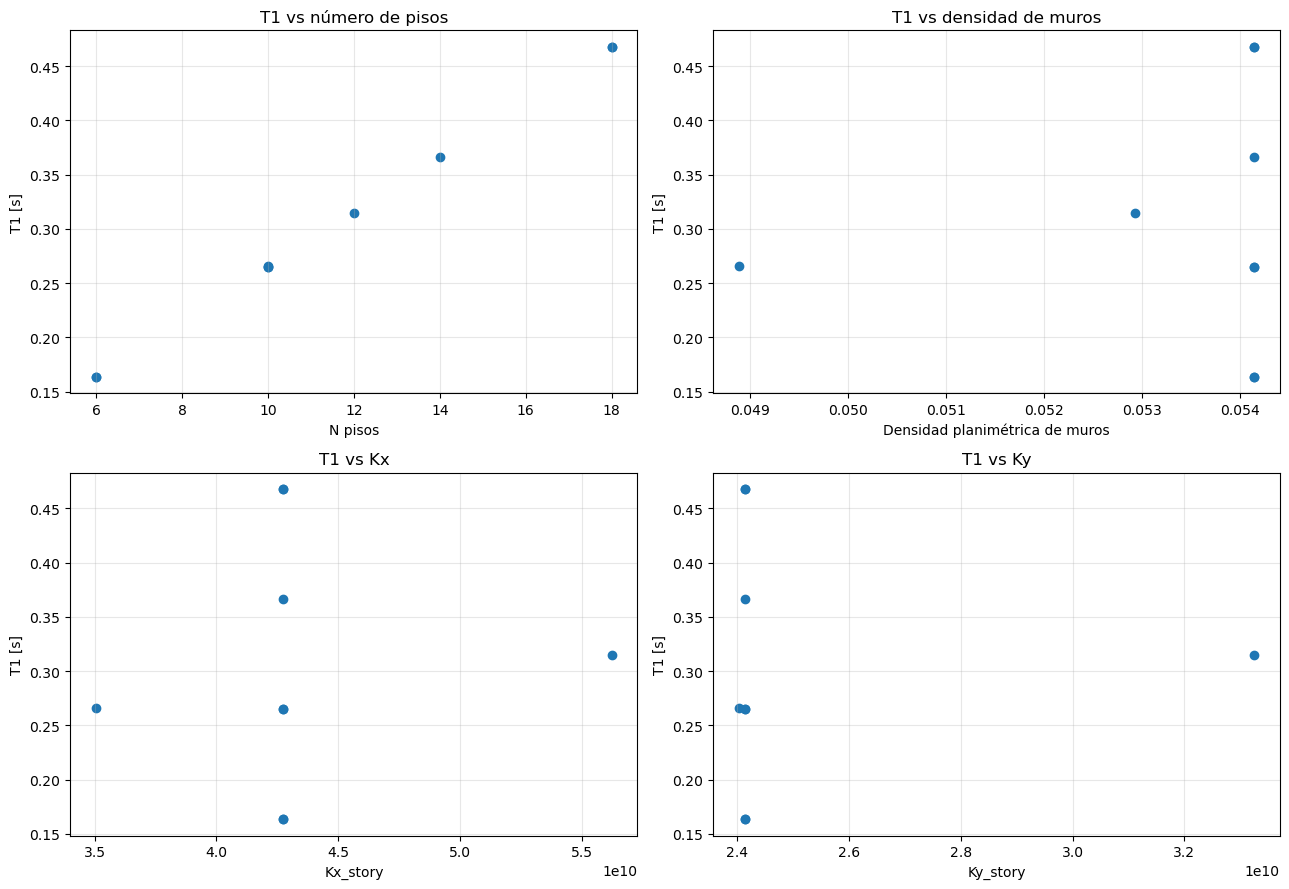

In [16]:
# ============================================================
# CELDA 16 — GRÁFICOS DE AUDITORÍA
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].scatter(audit_df["N_pisos"], audit_df["T1_s"])
axes[0,0].set_xlabel("N pisos")
axes[0,0].set_ylabel("T1 [s]")
axes[0,0].set_title("T1 vs número de pisos")
axes[0,0].grid(True, alpha=0.3)

axes[0,1].scatter(audit_df["wall_density_plan"], audit_df["T1_s"])
axes[0,1].set_xlabel("Densidad planimétrica de muros")
axes[0,1].set_ylabel("T1 [s]")
axes[0,1].set_title("T1 vs densidad de muros")
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(audit_df["Kx_story"], audit_df["T1_s"])
axes[1,0].set_xlabel("Kx_story")
axes[1,0].set_ylabel("T1 [s]")
axes[1,0].set_title("T1 vs Kx")
axes[1,0].grid(True, alpha=0.3)

axes[1,1].scatter(audit_df["Ky_story"], audit_df["T1_s"])
axes[1,1].set_xlabel("Ky_story")
axes[1,1].set_ylabel("T1 [s]")
axes[1,1].set_title("T1 vs Ky")
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Explicación

La tendencia esperada es:

$$
T_1\propto\sqrt{\frac{M}{K}}
$$

Por eso:

- más masa suele aumentar el período
- más rigidez suele disminuir el período
- más pisos suelen aumentar \(T_1\), pero no necesariamente de forma perfecta caso a caso


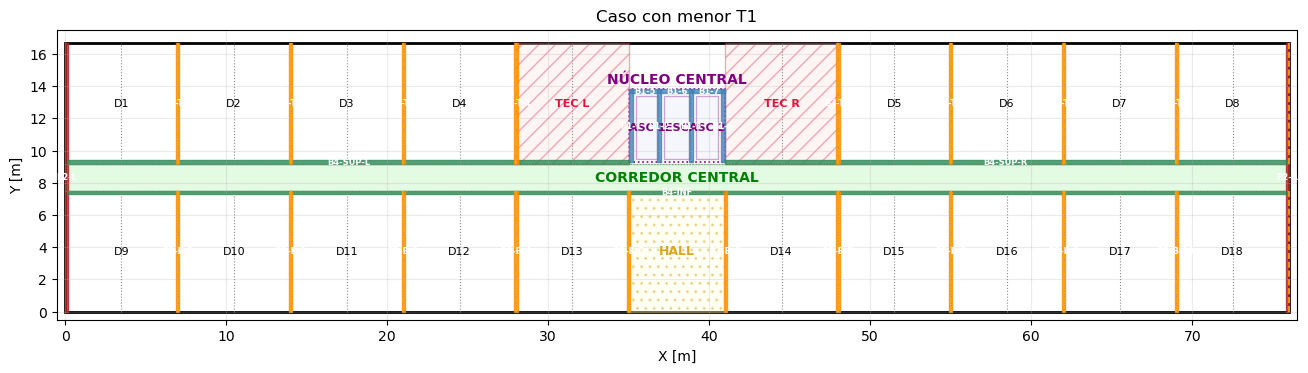

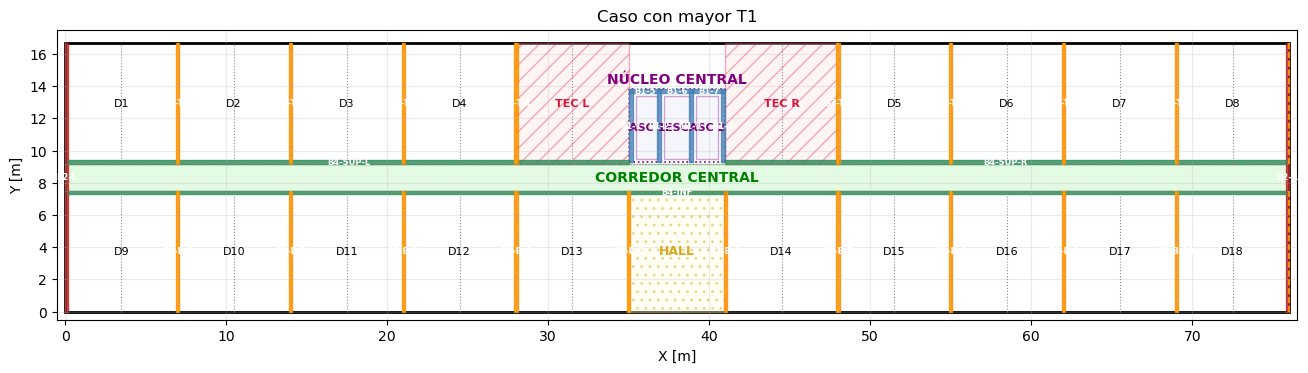

CASO MENOR T1
{'H_total_m': 16.200000000000003,
 'Ktheta_story': 12277306423580.178,
 'Kx_Ky_ratio': 1.7699403718476798,
 'Kx_story': 42732922947.40217,
 'Ky_story': 24143707679.14194,
 'Lx_m': 76.0,
 'Ly_m': 16.7,
 'M_total_kg': np.float64(5759295.98792656),
 'N_pisos': 6,
 'T1_s': np.float64(0.16358545317861578),
 'T2_s': np.float64(0.1629512220175311),
 'T3_s': np.float64(0.12296042729725659),
 'W_floor_kN': 9519.0,
 'W_roof_kN': 8884.4,
 'W_total_kN': 56479.4,
 'acc_x_last': 0.9999999999999997,
 'acc_y_last': 1.0,
 'case_id': 'N06_A',
 'geometry_pass': True,
 'modal_pass': True,
 'n90_x': 6,
 'n90_y': 4,
 'n_deptos_piso': 18,
 'n_walls': 30,
 'n_walls_structural': 69,
 'roof_mass_factor': np.float64(0.9333333333333333),
 'suelo': 'A',
 'wall_density_plan': 0.05414434289316104,
 'zona': 2}

CASO MAYOR T1
{'H_total_m': 48.6,
 'Ktheta_story': 12277306423580.178,
 'Kx_Ky_ratio': 1.7699403718476798,
 'Kx_story': 42732922947.40217,
 'Ky_story': 24143707679.14194,
 'Lx_m': 76.0,
 'Ly_m': 

In [17]:
# ============================================================
# CELDA 17 — VISUALIZAR CASOS CRÍTICOS
# ============================================================
def show_case_plan_from_output(case_out, title=None):
    p = case_out["params"]
    g = case_out["geom"]
    fig, ax = plt.subplots(figsize=(16, 7))
    try:
        plot_family_B_plan(g, p, ax=ax, show_labels=True, cfg=FAMILIA_B_CFG)
    except TypeError:
        familia_core.FAMILIA_B_CFG = FAMILIA_B_CFG
        plot_family_B_plan(g, p, ax=ax, show_labels=True)
    if title is None:
        title = f"case_id={case_out['row']['case_id']} | N={p['N_pisos']} | T1={case_out['row']['T1_s']:.3f}s"
    ax.set_title(title)
    plt.show()

idx_min = audit_df["T1_s"].idxmin()
idx_max = audit_df["T1_s"].idxmax()

case_min = audit_cases[idx_min]
case_max = audit_cases[idx_max]

show_case_plan_from_output(case_min, title="Caso con menor T1")
show_case_plan_from_output(case_max, title="Caso con mayor T1")

print("CASO MENOR T1")
pprint(case_min["row"])

print("\nCASO MAYOR T1")
pprint(case_max["row"])


In [18]:
# ============================================================
# CELDA 18 — CASOS ALEATORIOS DE AUDITORÍA
# ============================================================
random_cases = []

for i in range(N_MUESTRAS_AUDIT):
    p_i = build_params_B(
        FAMILIA_B_CFG,
        randomize=True,
        seed=int(SEED_AUDIT + i),
        overrides={
            "activar_B2": 1,
            "activar_B3": 1,
        }
    )
    g_i = build_family_B_geometry(p_i)

    try:
        out_i = analyze_family_B_modal_case(p_i, g_i, case_id=f"rnd_{i:03d}")
        random_cases.append(out_i)
    except Exception as e:
        print(f"Falla rnd_{i:03d}: {type(e).__name__}: {e}")

random_df = pd.DataFrame([c["row"] for c in random_cases])
display(random_df)

print("Tasa geometry_pass:", random_df["geometry_pass"].mean() if len(random_df) else np.nan)
print("Tasa modal_pass   :", random_df["modal_pass"].mean() if len(random_df) else np.nan)


,case_id,N_pisos,suelo,zona,Lx_m,Ly_m,H_total_m,n_deptos_piso,M_total_kg,W_floor_kN,...,Kx_Ky_ratio,T1_s,T2_s,T3_s,n90_x,n90_y,acc_x_last,acc_y_last,geometry_pass,modal_pass
0,rnd_000,8,A,1,106.699163,16.489283,23.2,26,9.239519e+06,11436.052754,...,1.624906,0.176818,0.176639,0.138711,6,4,1.000000,1.000000,True,True
1,rnd_001,6,C,1,88.603223,15.847698,16.8,22,5.512591e+06,9127.021105,...,1.707559,0.156098,0.154777,0.119456,6,4,1.000000,1.000000,True,True
2,rnd_002,11,B,1,76.990177,17.221165,31.9,18,9.599211e+06,8618.093542,...,1.893371,0.305720,0.301935,0.222180,6,4,1.000000,1.000000,True,True
3,rnd_003,16,A,2,57.302159,16.548605,43.2,14,1.232883e+07,7586.166459,...,2.073697,0.409280,0.398910,0.284216,6,4,0.995292,0.999983,True,True
4,rnd_004,11,C,1,50.088526,17.155353,28.6,10,7.666997e+06,6874.290879,...,1.676114,0.269595,0.267707,0.206780,6,5,1.000000,1.000000,True,True
5,rnd_005,11,D,1,90.758307,17.429875,31.9,22,1.411458e+07,12655.247686,...,1.872029,0.305599,0.303972,0.223355,6,4,1.000000,1.000000,True,True
6,rnd_006,12,A,3,62.767721,16.643772,34.8,14,8.895163e+06,7312.841386,...,1.682195,0.319654,0.318766,0.246458,6,4,1.000000,1.000000,True,True
7,rnd_007,7,C,1,106.506517,16.883515,19.6,26,1.017680e+07,14385.635366,...,1.715927,0.220082,0.219225,0.167356,6,5,1.000000,1.000000,True,True
8,rnd_008,6,B,2,79.780862,16.903428,15.6,18,5.294361e+06,8765.705259,...,1.700505,0.146440,0.146177,0.112298,6,4,1.000000,1.000000,True,True
9,rnd_009,8,D,3,64.975248,16.771722,21.6,14,6.167340e+06,7628.227440,...,1.680578,0.204559,0.204038,0.157794,6,4,1.000000,1.000000,True,True


Tasa geometry_pass: 1.0
Tasa modal_pass   : 1.0


## 🏁 Hito — Resumen final y veredicto de aprobación

Combina los casos representativos y aleatorios en `all_audit_df`, calcula el **resumen global** (tasas de aprobación, rango y mediana de $T_1$, máximos de `n90`) y evalúa la bandera `notebook2_ready`: se aprueba si las tasas geométrica y modal superan el 95% y los $T_1$ son finitos.

**Se obtiene:** el diccionario `summary`, la tabla consolidada y el **veredicto de aprobación preliminar** del Notebook 2.

In [19]:
# ============================================================
# CELDA 19 — RESUMEN FINAL
# ============================================================
all_audit_df = pd.concat([audit_df, random_df], ignore_index=True)

summary = {
    "n_cases": len(all_audit_df),
    "geometry_pass_rate": all_audit_df["geometry_pass"].mean(),
    "modal_pass_rate": all_audit_df["modal_pass"].mean(),
    "T1_min": all_audit_df["T1_s"].min(),
    "T1_median": all_audit_df["T1_s"].median(),
    "T1_max": all_audit_df["T1_s"].max(),
    "n90_x_max": all_audit_df["n90_x"].max(),
    "n90_y_max": all_audit_df["n90_y"].max(),
}

pprint(summary)
display(all_audit_df.describe(include="all"))

notebook2_ready = all([
    summary["geometry_pass_rate"] >= 0.95,
    summary["modal_pass_rate"] >= 0.95,
    np.isfinite(summary["T1_min"]),
    np.isfinite(summary["T1_max"]),
])

if notebook2_ready:
    print("Notebook 2 APROBADO preliminarmente.")
else:
    print("Notebook 2 NO aprobado todavía. Revisar geometría, rigidez o extracción modal.")


{'T1_max': np.float64(0.46765992845039916),
 'T1_median': np.float64(0.2695953636807534),
 'T1_min': np.float64(0.1464399826751787),
 'geometry_pass_rate': np.float64(0.9523809523809523),
 'modal_pass_rate': np.float64(1.0),
 'n90_x_max': np.int64(6),
 'n90_y_max': np.int64(5),
 'n_cases': 21}


,case_id,N_pisos,suelo,zona,Lx_m,Ly_m,H_total_m,n_deptos_piso,M_total_kg,W_floor_kN,...,Kx_Ky_ratio,T1_s,T2_s,T3_s,n90_x,n90_y,acc_x_last,acc_y_last,geometry_pass,modal_pass
count,21,21.000000,21,21.000000,21.000000,21.000000,21.00000,21.000000,2.100000e+01,21.000000,...,21.000000,21.000000,21.000000,21.000000,21.0,21.000000,21.000000,21.000000,21,21
unique,21,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1
top,N06_A,NaN,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True
freq,1,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20,21
mean,NaN,11.190476,NaN,1.952381,78.309283,16.758397,30.60000,18.571429,1.073086e+07,9601.742720,...,1.751900,0.290831,0.289027,0.218960,6.0,4.142857,0.998772,0.999941,NaN,NaN
std,NaN,4.214487,NaN,0.804748,16.798524,0.324297,11.37906,4.780914,4.588740e+06,2247.880296,...,0.118257,0.105048,0.103898,0.076485,0.0,0.358569,0.002021,0.000126,NaN,NaN
min,NaN,6.000000,NaN,1.000000,47.732005,15.847698,15.60000,10.000000,5.294361e+06,5127.333475,...,1.459518,0.146440,0.146177,0.112298,6.0,4.000000,0.994596,0.999658,NaN,NaN
25%,NaN,8.000000,NaN,1.000000,76.000000,16.700000,21.60000,18.000000,7.666997e+06,8618.093542,...,1.690665,0.204559,0.204038,0.157794,6.0,4.000000,0.996754,1.000000,NaN,NaN
50%,NaN,11.000000,NaN,2.000000,76.000000,16.700000,28.60000,18.000000,9.641967e+06,9519.000000,...,1.769940,0.269595,0.267707,0.219794,6.0,4.000000,1.000000,1.000000,NaN,NaN
75%,NaN,14.000000,NaN,3.000000,88.603223,16.883515,37.80000,22.000000,1.352464e+07,9519.000000,...,1.769940,0.366250,0.364830,0.275295,6.0,4.000000,1.000000,1.000000,NaN,NaN


Notebook 2 APROBADO preliminarmente.


## 💾 Hito — Exportación de resultados intermedios

Paso final que persiste los entregables en `dataset/intermediate/`: un **CSV** con el resumen de auditoría (`familia_B_modal_audit_summary.csv`) y un **pickle** (`familia_B_modal_audit_cases.pkl`) con los casos completos, la tabla resumen y la configuración de la corrida (semillas, rutas e identificador del modelo de rigidez).

**Se obtiene:** los archivos intermedios que dejan el análisis modal trazable y reutilizable por la etapa de generación masiva del dataset.

In [20]:
# ============================================================
# CELDA 20 — GUARDAR RESULTADOS INTERMEDIOS
# ============================================================
OUT_DIR = Path("dataset") / "intermediate"
OUT_DIR.mkdir(parents=True, exist_ok=True)

csv_path = OUT_DIR / "familia_B_modal_audit_summary.csv"
pkl_path = OUT_DIR / "familia_B_modal_audit_cases.pkl"

all_audit_df.to_csv(csv_path, index=False)

with open(pkl_path, "wb") as f:
    pickle.dump({
        "representative_cases": audit_cases,
        "random_cases": random_cases,
        "summary_df": all_audit_df,
        "config": {
            "N_MODOS_MAX": N_MODOS_MAX,
            "SEED_AUDIT": SEED_AUDIT,
            "N_MUESTRAS_AUDIT": N_MUESTRAS_AUDIT,
            "FAMILIA_B_JSON": str(FAMILIA_B_JSON),
            "FAMILIA_B_CORE": str(FAMILIA_B_CORE),
            "stiffness_model": "directional_walls_B4_discretized_openings_v1",
        }
    }, f)

print("Archivos guardados:")
print(csv_path)
print(pkl_path)


Archivos guardados:
dataset\intermediate\familia_B_modal_audit_summary.csv
dataset\intermediate\familia_B_modal_audit_cases.pkl
